In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import ticker

In [2]:
data_path = Path("./data")
figure_path = Path("./figures")

In [3]:
NUM_TREES = 9

tree_properties = pd.DataFrame()
TREE_NAMES = [
    "H. courbaril",
    "H. impetiginosus",
    "L. grandiflora",
    "H. serratifolius",
    "T. aurea",
    "C. trichotoma",
    "L. kunthiana",
    "S. terebinthifolia",
    "M. nyctitans",
]

TREE_COMMON_NAMES = [
    "Courbaril",
    "Pink ipê",
    "acoita-grandiflora",
    "Yellow poui",
    "Caribbean trumpet-tree",
    "louro-da-serra",
    "Licania kunthiana",
    "Brazilian peppertree",
    "Espuela De Gallo",
]

INITIAL_COUNTS = [8015, 7762, 5372]

In [4]:
def load_benefit_data(path: os.PathLike, year_offset: int = 0) -> pd.DataFrame:
    with Path(path).open() as file:
        data = json.load(file)

    attributes = []

    for i in range(1, NUM_TREES + 1):
        for year, (elem_annual, elem_cumulative) in enumerate(
            zip(
                data["data"]["trees"][str(i)]["benefits"]["annual"]["category"],
                data["data"]["trees"][str(i)]["benefits"]["cumulative"]["category"],
                strict=True,
            ),
        ):
            attributes.append(
                {
                    "tree": int(i - 1),
                    "name": TREE_NAMES[i - 1],
                    "year": int(year) + year_offset,
                    "height": elem_annual["height"],
                    "diameter": elem_annual["diameter"],
                    "crown_area": elem_annual["crown-area"],
                    "count": elem_annual["count"],
                    "co2": elem_cumulative["carbon"]["carbon-dioxide"]["sequestration"],
                },
            )

    return (
        pd.DataFrame(attributes)
        .set_index(["tree", "year"])
        .sort_index()
        .assign(total_crown_area=lambda df: df["crown_area"] * df["count"])
    )

In [5]:
df_attributes_first = load_benefit_data(data_path / "benefits" / "year_1.json")
df_attributes_after = (
    load_benefit_data(data_path / "benefits" / "year_after.json", year_offset=1)
    .reset_index()
    .query("year > 1")
    .set_index(["tree", "year"])
)
df_attributes = pd.concat([df_attributes_first, df_attributes_after]).sort_index()

# Grupos de crecimiento

In [6]:
final_diameters = df_attributes.xs(key=40, level="year")["diameter"].to_numpy()
similar_growth_groups = sorted(
    [np.where(final_diameters == d)[0].tolist() for d in np.unique(final_diameters)],
    key=lambda x: x[0],
)
growth_groups_labels = [
    "\n".join(TREE_NAMES[i] for i in group) for group in similar_growth_groups
]

# Gráficas

## Tasa de crecimiento vs. DBH

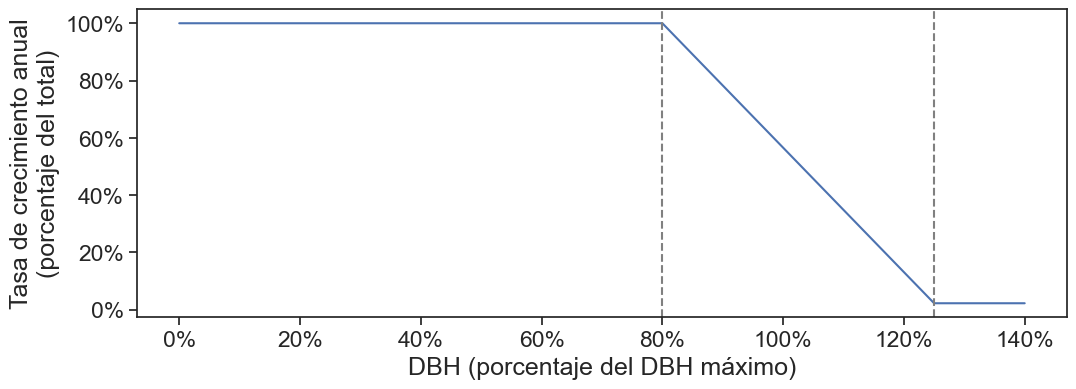

In [7]:
dbh = [0, 0.8, 1.25, 1.4]
rate = [1, 1, 0.022, 0.022]

sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dbh, rate)
ax.set_xlabel("DBH (porcentaje del DBH máximo)")
ax.set_ylabel("Tasa de crecimiento anual\n(porcentaje del total)")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.axvline(0.8, c="gray", ls="--")
ax.axvline(1.25, c="gray", ls="--")
fig.savefig(figure_path / "growth_rate_vs_dbh.jpg", dpi=300, bbox_inches="tight")

## DBH

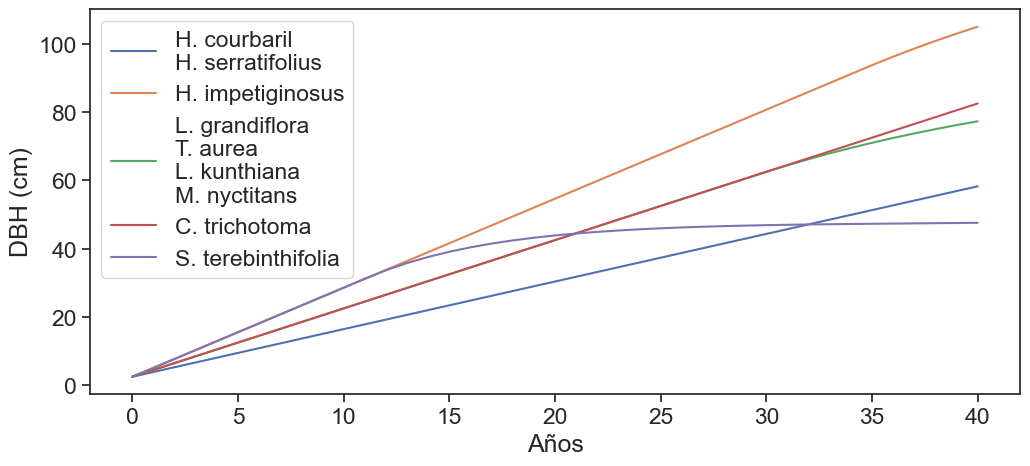

In [8]:
sns.set_theme(style="ticks", font_scale=1.5)

fig, ax = plt.subplots(figsize=(12, 5))
for indices, label in zip(similar_growth_groups, growth_groups_labels, strict=True):
    ax.plot(
        range(41),
        df_attributes.xs(key=indices[0], level="tree")["diameter"],
        label=label,
    )

ax.set_xlabel("Años")
ax.set_ylabel("DBH (cm)")
ax.legend()
fig.savefig(figure_path / "dbh_over_time.jpg", dpi=300, bbox_inches="tight")

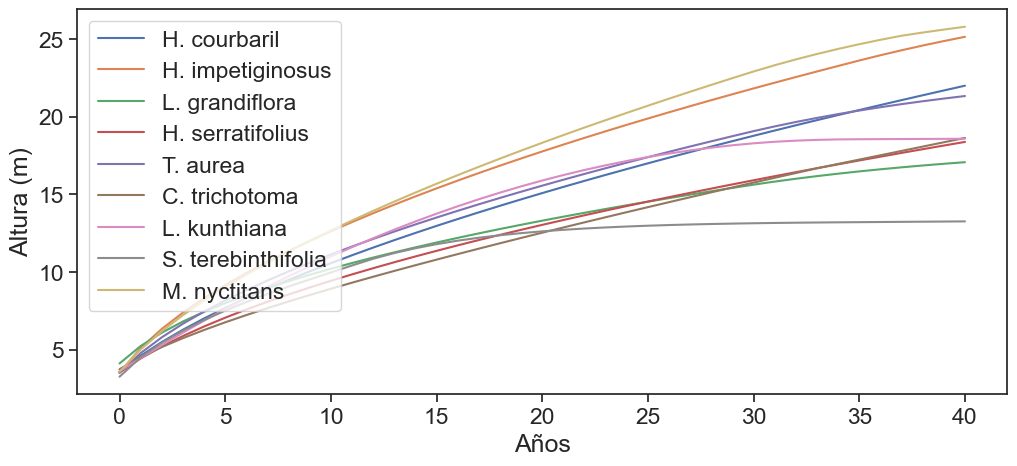

In [9]:
sns.set_theme(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(NUM_TREES):
    ax.plot(
        range(41),
        df_attributes.xs(key=i, level="tree")["height"],
        label=TREE_NAMES[i],
    )

ax.set_xlabel("Años")
ax.set_ylabel("Altura (m)")
ax.legend()
fig.savefig(figure_path / "height_over_time.jpg", dpi=300, bbox_inches="tight")

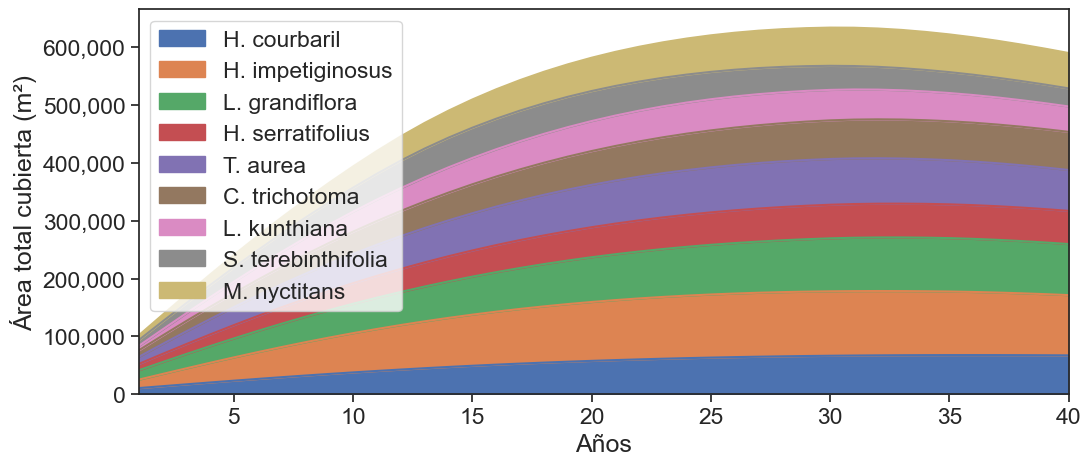

In [10]:
sns.set_theme(style="ticks", font_scale=1.5)

fig, ax = plt.subplots(figsize=(12, 5))
df_attributes.reset_index().pivot_table(
    index="year",
    columns="name",
    values="total_crown_area",
)[TREE_NAMES].plot.area(ax=ax)

ax.set_xlim(1, 40)
ax.set_xlabel("Años")
ax.set_ylabel("Área total cubierta (m²)")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

ax.legend().set_title("")

fig.savefig(figure_path / "crown_area_over_time.jpg", dpi=300, bbox_inches="tight")

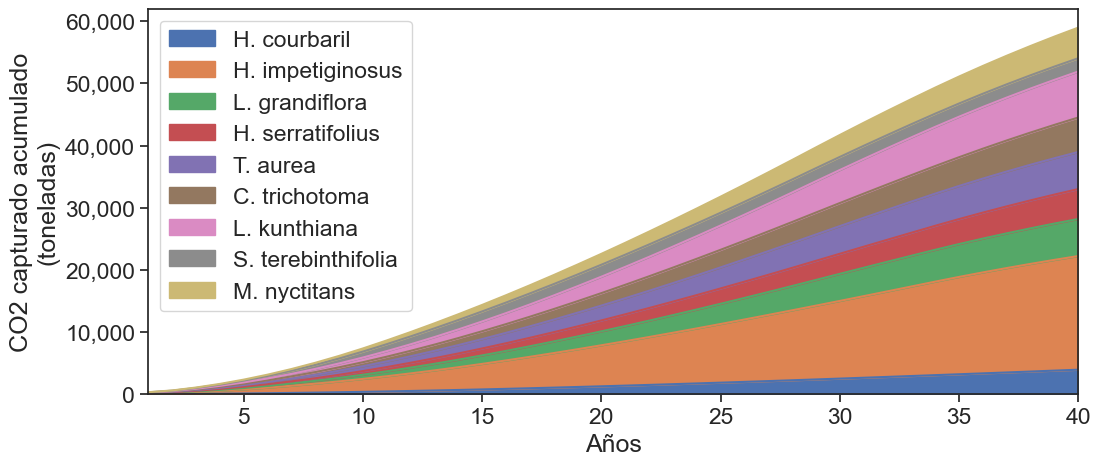

In [12]:
sns.set_theme(style="ticks", font_scale=1.5)

fig, ax = plt.subplots(figsize=(12, 5))
df_attributes.reset_index().pivot_table(
    index="year",
    columns="name",
    values="co2",
)[TREE_NAMES].divide(1e3).plot.area(ax=ax)

ax.set_xlim(1, 40)
ax.set_xlabel("Años")
ax.set_ylabel("CO2 capturado acumulado\n(toneladas)")
ax.legend().set_title("")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

fig.savefig(
    figure_path / "carbon_sequestration_over_time.jpg",
    dpi=300,
    bbox_inches="tight",
)

In [13]:
emission_factor = 0.0545
per_capita_energy_consumption_kwh = 2_916
cost_per_kwh_usd = 0.16

co2_captured = df_attributes.xs(40, level="year")["co2"].sum()
gwh_equivalent = co2_captured / emission_factor / 1e6

print(f"CO2 capturado acumulado en 40 años: {co2_captured / 1e3:.2f} toneladas")
print(f"Equivalente en GWh de electricidad generada: {gwh_equivalent:.2f}")
print(f"Equivalente de personas en 40 años: {gwh_equivalent * 1e6 / per_capita_energy_consumption_kwh / 40:.0f} personas")
print(f"Costo equivalente: ${gwh_equivalent * 1e6 * cost_per_kwh_usd:,.0f}")

CO2 capturado acumulado en 40 años: 58977.54 toneladas
Equivalente en GWh de electricidad generada: 1082.16
Equivalente de personas en 40 años: 9278 personas
Costo equivalente: $173,145,064
